In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import analysis_utils as auti
import file_utils as futi
import event_utils as euti
import event_io as eio


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers
import pickle

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )
importlib.reload( futi )
importlib.reload( euti )
importlib.reload( eio )

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
# This allow both dict.key and dict['key'] syntax
class AttrDict(dict):
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")

    def __setattr__(self, key, value):
        self[key] = value

    def __delattr__(self, key):
        try:
            del self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")



In [3]:
recalculate = True # False 
read_stored_El = not recalculate

print( f"Redoing A and Els ={recalculate}, Readin stored = {read_stored_El} ")


Redoing A and Els =True, Readin stored = False 


In [4]:
%%time
if recalculate == False and read_stored_El==True:
    
    #fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp.pkl'
    #fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_35N-70N_ocean_EvZ10km_rho_epwp.pkl'
    #fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_ftp5X5.pkl'
    #fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_ftp5X5_test.pkl'
    #fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/c124_dyamond1_prod2_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp.pkl'
    #fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/c124_dyamond1_prod2_2016-08-01-10800-x-2016-08-31-75600_35N-70N_ocean_EvZ10km_rho_epwp.pkl'


    #fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_v2.pkl'  
    #fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_v3.pkl'
    #fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_35N-70N_ocean_EvZ10km_rho_epwp_v2.pkl'
    
    #fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_ftp5X5_v2.pkl'
    #fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_subt_ftp5X5_v3.pkl'

    fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_subt_ftp5X5_v3.pkl'
    fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_35N-70N_ocean_EvZ10km_rho_epwp_subt_ftp5X5_v3.pkl'

    
    print( f"Reading in stored = {read_stored_El} from \n {fEl1} ")
    with open(f'{fEl1}', 'rb') as f:
        El = pickle.load(f)
    
    print( f"Reading in stored = {read_stored_El} from \n {fEl2} ")
    with open(f'{fEl2}', 'rb') as f:
        El2 = pickle.load(f)


CPU times: user 2 μs, sys: 1 μs, total: 3 μs
Wall time: 5.48 μs


In [5]:
%%time
importlib.reload( futi )
importlib.reload( nuti )
if recalculate == True and read_stored_El==False:
    nsteps=None
    start_date=None
    super_lat_range = [-90.,90.]  #[-85,-30]
    #super_lat_range = [-80.,-30.]  #[-85,-30]
    #super_lat_range = [30.,80.] # Northern Summer!!!!!!!!!!
    #case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x02'   , False #, [2004,7,15,0], 248
    #case, process_ncdata = 'c153_topfix_ne240pg3_FMTHIST_xic_x02'   , False #, [2004,7,15,0], 248
    #case, process_ncdata = 'c153_topfix_ne240pg3_FMTHIST_xic_x03'   , False #, [2004,7,15,0], 248
    #case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x03'   , False #, [2007,7,15,0], 248
    #case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x03'   , False #, [2007,8,15,0], 124
    case, process_ncdata  = 'cam77_dyamond1_prod1'    , False
    #case, process_ncdata  = 'c124_dyamond1_prod2'    , False
    #case , process_ncdata = 'xy-rdg-mm-front'    , True
    #nsteps=8
    A = futi.read_case( case=case, nsteps=nsteps, start_date=start_date , super_lat_range=super_lat_range ) # , nsteps = 31*8 )
    
    time, zlev, lat, lon = A.time, A.zlev, A.lat, A.lon



  nsteps=247 
/glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-01-10800.nc /glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-31-75600.nc
 Dataset opened  , dtype of U,V float32 float32 
 Dataset opened  trimmed. -89.76 to  89.76 
Read subsetted X w open_mfdata_set  165.7307 seconds
extracted upwp,...U,V,T etc  117.6652 seconds
Vorticity calc  4.8962 seconds
rho geopht pint ... calc  39.7093 seconds
rho calc ... epwp  8.3881 seconds
(247, 58, 192, 288)
(247, 58, 192, 288)
(247, 58, 192, 288)
(247, 58, 192, 288)
tilting calc  49.5362 seconds
this is Sphere_grad_vec in numerical_utils in HiRes_ana
dlat has been adjusted to account for FUCKED UP CRAPPY fv1x1 SCRIP FILE IN CESMDATA INPUTs!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
frontogenesis calc  410.9236 seconds
stability calc  3.3438 seconds
CPU times: user 1min 19s, sys: 8min 11s, total: 9min 31s
Wall time: 14min 44s

looking at Z=9996.58935
There are a total of 13658112 gridpoints in [0, 360]X[-60, -40] 
>>> ======== Initial analysis in make_El ===========
    note: these numbers are based on grid points NOT local maxima 
 fraction=12.50% of total epwp is in events with epwp > 0.20281. Carried by N= 44142 events or  0.32%  
 fraction= 6.25% of total epwp is in events with epwp > 0.33342. Carried by N= 14529 events or  0.11%  
 Threshholds [array([2.02805415e-01, 1.00000000e+06]), array([3.33421081e-01, 1.00000000e+06])]
   ======== Initial analysis in make_El =========== <<< 
 ... 
>>> ======== second sort in make_ds ===========
Events at Z=9996.58935
Peak footprint=5X5
Total events 24429 in [0, 360]X[-60, -40] for thresh=[0.0, 1000000.0] BEFORE topo filtering. Peak footprint=5X5
   ======== second sort in make_ds =========== <<<
relative time array: [0.] 
N events: = 24429 BEFORE any topo filtering !!!! 
N events: = 19889 AFTER topo filtering !!!! 
 shape of ds.epwp_max after orographic excl (if a

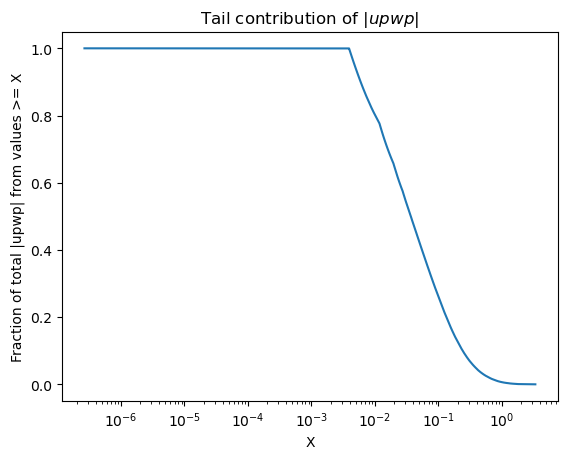

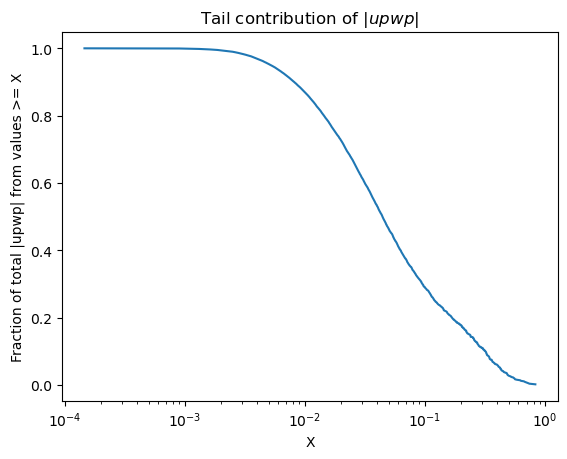

In [6]:
%%time
#################################################################
# Make event lists ... and composites
importlib.reload(eio)
importlib.reload(euti)
importlib.reload(auti)
if recalculate == True and read_stored_El==False:
    
    #zlev_event=12_000. # before too much filtering ...
    zlev_event=10_000. # before too much filtering ...
    lat_range=  [-60,-40] #[-70,-60] #[-60,-40]
    lon_range=[0,360] # [0,60]
    exclude_orography=True
    subsample_time = True
    
    #fracs=[1.0,0.25,0.125,0.0625]+.
    fracs=[1.0,0.995,]
    fracs=[0.125,0.0625,]
    
    #fracs=[0.995,0.90,0.50,0.25,0.125,0.0625]
    #fracs=[0.95,0.90,0.50,0.25,0.125,0.0625]
    #fracs=[0.125,]
    
    El = euti.make_El(
                A=A, 
                fractions_for_thresholds=fracs,
                zlev_event=zlev_event, 
                lat_range=lat_range,
                lon_range=lon_range,
                exclude_orography= exclude_orography,
                peak_footprint=(5,5),
                subsample_time=subsample_time,
                return_after_stage1=False
               )
    
    #f=eio.pickle_write(El)
    #print(f)

In [7]:
importlib.reload( eio )
print(El[1].ds.sizes['index']/El[0].ds.sizes['index'])

El0=El[0]
thresh_ = f"{El0.Frac_of_total_epwp:.4f}-{El0.threshold[1]:.4g}".replace('.','d').replace('+','') 
print(thresh_)
print( eio.make_base_filename(El0) )

0.384
0d1250-1e06
cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_subt_ftp5X5_Frac12%_v4


In [8]:
importlib.reload( auti )
importlib.reload( euti )

zeta_4D_x , time4D,lat4D,lon4D = auti.cube4D_ds( event_ds=El[0].ds, aa=A.zeta , lon=lon, lat=lat, window= [4,5,5]  , TZHkey='tzyx', lat_range=lat_range, lon_range=lon_range , subsample_time=True)

print( zeta_4D.shape )
print( zeta_4D_x.shape )
print( El[0].zeta_4D.shape )

relative time array: [-4. -2.  0.] 


NameError: name 'zeta_4D' is not defined

In [ ]:

plt.plot( zeta_4D[:,0,40,5,5] )
plt.plot( zeta_4D_x[:,0,40,5,5] )
#plt.plot( El[0].zeta_4D[:,3,40,5,5] )


In [ ]:

plt.plot( zeta_4D[:,4,40,5,5] )
plt.plot( zeta_4D_x[:,2,40,5,5] )
plt.plot( El[0].zeta_4D[:,3,40,5,5] )


In [ ]:
%%time
#################################################################
# Make event lists ... and composites
importlib.reload(euti)
importlib.reload(auti)
if recalculate == True and read_stored_El==False:
    
    #zlev_event=15_000. #23_000.
    #zlev_event=12_000. # Summer
    zlev_event=13_000. # Summer
    lat_range=  [35,70] # Northern Summer!!!!!!!!!!
    lon_range=[0,360] # [0,60]
    exclude_orography=True
    
    fracs=[0.995,0.90,0.50,0.25,0.125,0.0625]
    #fracs=[0.95,0.90,0.50,0.25,0.125,0.0625]
    
    El2 = euti.make_El(
                A=A, 
                fractions_for_thresholds=fracs,
                zlev_event=zlev_event, 
                lat_range=lat_range,
                lon_range=lon_range,
                exclude_orography= exclude_orography,
                peak_footprint=(3,3),
                return_after_stage1=False
               )
    
    #f=eio.pickle_write(El2)
    #print(f)

In [ ]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El , plot_v=True )
auti.plot_xavg_compos( fld='tilt_4D', El=El )
auti.plot_xavg_compos( fld='fgf_4D', El=El )
auti.plot_xavg_compos( fld='thpwp_4D', El=El )


In [ ]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El2, plot_v=True  )
auti.plot_xavg_compos( fld='tilt_4D', El=El2 )
auti.plot_xavg_compos( fld='fgf_4D', El=El2 )
auti.plot_xavg_compos( fld='thpwp_4D', El=El2 )


In [ ]:
#import random_forest as RF

Eco=   El[0]  #euti.combine_event_dicts(El[3], El[1], label_key='event_strength')
zlev=El[0].zlevA
z0=np.argmin( np.abs( zlev-0.))
z3=np.argmin( np.abs( zlev-3000.))
z5=np.argmin( np.abs( zlev-5000.))
z6=np.argmin( np.abs( zlev-6000.))
z7=np.argmin( np.abs( zlev-7000.))
z10=np.argmin( np.abs( zlev-10000.))
z11=np.argmin( np.abs( zlev-11000.))
z12=np.argmin( np.abs( zlev-12000.))
z15=np.argmin( np.abs( zlev-15000.))


print( np.shape(Eco.u_4D ))
dt = Eco.timeA[1] - Eco.timeA[0] 
print(dt.total_seconds())

In [ ]:
usp = np.sqrt( El[5].u_4D**2 + El[5].v_4D**2 )
usp_v=np.mean( usp[:,-1,:,:,:], axis=(0,2,3) )
usp2 = np.sqrt( El2[5].u_4D**2 + El2[5].v_4D**2 )
usp2_v=np.mean( usp2[:,-1,:,:,:], axis=(0,2,3) )

plt.plot(usp_v,zlev )
plt.plot(usp2_v,zlev )



In [ ]:
epwp_v=np.mean( El[0].epwp_4D[:,-1,:,:,:], axis=(0,2,3) )
thpwp_v=np.mean( 5*El[0].thpwp_4D[:,-1,:,:,:], axis=(0,2,3) )

plt.plot(epwp_v,zlev,color='blue',linestyle=':' )
plt.plot(thpwp_v,zlev,color='red' , linestyle=':')

epwp_v=np.mean( El[5].epwp_4D[:,-1,:,:,:], axis=(0,2,3) )
thpwp_v=np.mean( 5*El[5].thpwp_4D[:,-1,:,:,:], axis=(0,2,3) )

plt.plot(epwp_v,zlev,color='blue' )
plt.plot(thpwp_v,zlev,color='red' )

plt.plot(0.*zlev,zlev,color='black',linestyle='--'  )




In [ ]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.use('module://matplotlib_inline.backend_inline')

In [ ]:
##################
import importlib                                                                                                                                                                                                                                                                                              
import mlp_utils as mlu  
import predictors as Predi
importlib.reload(mlu) 
#importlib.reload(RF)
importlib.reload(Predi)
importlib.reload(eio)


Eco=El[0]
nv,nt_v,nz_v,ny_v,nx_v = np.shape( Eco.epwp_4D )

#Eco['abs_zeta_4D'] = np.abs( Eco['zeta_4D'] )
zlev=El[0].zlevA

MyHyperparameters = Predi.reset_hyperparameters()

#And you're now set up to do your lr_patience=15, min_lr=1e-7 experiment cleanly —

"""
MyHyperparameters['predictorSet']    = 'MovMtn-like'
MyHyperparameters['yrange']          = [1, -1]
MyHyperparameters['use_predictors']  = ['tilt_4D','zeta_4D','stab_4D']  #,'u_4D','v_4D']
#MyHyperparameters['use_predictors']  = ['fgf_4D', 'zeta_4D', 'stab_4D']
MyHyperparameters['time_average']    = False
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['z_targ']          = z10
MyHyperparameters['lr_patience']     = 3
MyHyperparameters['patience']        = 100
MyHyperparameters['min_lr']          = 1e-6
MyHyperparameters['loss_power']      = 6.0
MyHyperparameters['hidden_dims']     = (8,8) #(16,16)  #(8,8)
MyHyperparameters['z_launch']        = 5_000.
MyHyperparameters['z_steer']        = 1_000.
"""

"""
MyHyperparameters['predictorSet']    = 'GWP-like'
MyHyperparameters['yrange']          = [1, -1]
MyHyperparameters['use_predictors']  = ['tilt_4D', 'zeta_4D', 'stab_4D']  #,'u_4D','v_4D']
#MyHyperparameters['use_predictors']  = ['fgf_4D', 'zeta_4D', 'stab_4D']
MyHyperparameters['time_average']    = True
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['z_targ']          = z10
MyHyperparameters['lr_patience']     = 3
MyHyperparameters['patience']        = 100
MyHyperparameters['min_lr']          = 1e-6
MyHyperparameters['loss_power']      = 4.0
MyHyperparameters['hidden_dims']     = (32,32)
"""


MyHyperparameters['predictorSet']    = 'original_default'
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D',  'tilt_4D', 'zeta_4D', ] #'fgf_4D',]
MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'tilt_4D', 'zeta_4D', 'stab_4D',]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'fgf_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'tilt_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'zeta_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','th_4D',]
MyHyperparameters['z_targ']          = z10
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['yrange']          = [1, -1]
#MyHyperparameters['yrange']          = [3, -3]
#MyHyperparameters['xrange']          = [3, -3]
MyHyperparameters['lr_patience']     = 15


"""
MyHyperparameters['predictorSet']    = 'Probe-steer-launch'
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D',  'tilt_4D', 'zeta_4D', ] #'fgf_4D',]
MyHyperparameters['use_predictors']  = ['stab_4D',  'tilt_4D', 'zeta_4D', ] #'fgf_4D',]
#MyHyperparameters['use_predictors']  = ['abs_zeta_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'fgf_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'tilt_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'zeta_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','th_4D',]
MyHyperparameters['z_targ']          = z12
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['yrange']          = [1, -1]
MyHyperparameters['z_steer']          = [1000,3000,5000,9000]
MyHyperparameters['z_launch']          = [5000,9000,11000]
MyHyperparameters['hidden_dims']     = (16,16)  #(8,8)

#MyHyperparameters['yrange']          = [3, -3]
#MyHyperparameters['xrange']          = [3, -3]
MyHyperparameters['lr_patience']     = 15
"""

"""
MyHyperparameters['predictorSet']    = 'Dynamic-steer-launch'
#MyHyperparameters['use_predictors'] = ['abs_zeta_4D','zeta_4D','tilt_4D']
MyHyperparameters['use_predictors'] = ['tilt_4D','zeta_4D','tilt_4D'  , 'precl_4D' ] #'thpwp_4D']  # These are the best
#MyHyperparameters['use_predictors'] = ['vmag_4D','zeta_4D','tilt_4D']
#MyHyperparameters['use_predictors'] = ['abs_zeta_4D','abs_zeta_4D','tilt_4D']
#MyHyperparameters['use_predictors'] = ['tilt_4D','zeta_4D','tilt_4D',]  #'thpwp_4D']
#MyHyperparameters['use_predictors'] = ['tilt_4D','tilt_4D','abs_zeta_4D', ]  #'thpwp_4D']

MyHyperparameters['z_targ']          = -1 #z10
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['yrange']          = [1, -1]
MyHyperparameters['trange']          = None #[nt_v-1, nt_v]
MyHyperparameters['hidden_dims']     = (16,16)  #(8,8)

#MyHyperparameters['yrange']          = [3, -3]
#MyHyperparameters['xrange']          = [3, -3]
MyHyperparameters['lr_patience']     = 15
"""

predictors, predictor_names, use_predictors, key_z, short_desc, yv = \
    Predi.build_predictor_set(Eco, zlev, MyHyperparameters)

mlp_model, mlp_results = mlu.fit_mlp_general(
    predictors      = predictors,
    predictor_names = predictor_names,
    target          = yv,
    event_times     = Eco.time4D,
    train_interval  = (48, 248),
    test_interval   = (0, 28),
    **{k: MyHyperparameters[k] for k in [
        'hidden_dims', 'dropout', 'batch_size', 'lr',
        'weight_decay', 'patience', 'max_epochs',
        'lr_patience', 'lr_factor', 'min_lr',
        'loss_power', 'log_predictor_patterns',
    ]}
)




mlu.plot_distributions(mlp_results, desc=short_desc  ) 

mlu.plot_mlp_results(mlp_results, top_n=20 ,desc=short_desc[0:200])


In [ ]:

meta = {
    'feat_scaler':   mlp_results['feat_scaler'],
    'target_scaler': mlp_results['target_scaler'],
    'log_pred_mask': mlp_results['log_pred_mask'],
}
device = 'cpu'  # or 'cuda' if you're on GPU

In [ ]:
######### TRANSFER LEARNING ????????  #################################################
from scipy import stats


Eco2 = El2[0]
Eco2['abs_zeta_4D'] = np.abs( Eco2['zeta_4D'] )

predictors_2, predictor_names, use_predictors, key_z, short_desc, yv_2 = \
    Predi.build_predictor_set(Eco2, zlev, MyHyperparameters)



################################

y_pred_2 = mlu.apply_mlp(mlp_model, meta, device, predictors_2)


print(y_pred_2.shape)
print(yv_2.shape)



eps = 1e-12
ly_pred_2       = np.log(np.maximum(y_pred_2,  eps))
ly_targ_2       = np.log(np.maximum(yv_2        ,  eps))
r_log, _ = stats.pearsonr(ly_targ_2, ly_pred_2)
print(r_log )

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))

# --- panel 1: log-log scatter ---
ax = axes
ax.scatter(ly_targ_2, ly_pred_2, alpha=0.3, s=10, color='steelblue')
lims = [min(ly_targ_2.min(), ly_pred_2.min()),
        max(ly_targ_2.max(), ly_pred_2.max())]
ax.plot(lims, lims, 'r--', lw=1)
r_log, _ = stats.pearsonr(ly_targ_2, ly_pred_2)
ax.set_xlabel('log(actual)')
ax.set_ylabel('log(predicted)')
ax.set_title(f'Log-space scatter  r={r_log:.3f}')

ax.text(0.5, -0.02, short_desc[0:180], ha='center', va='top', fontsize=9,
         transform=fig.transFigure)



In [ ]:
print( El[0].u_4D.shape )

In [ ]:
importlib.reload( auti )

plev=100_000. * np.exp( -zlev / 7000. )

fig,axs=plt.subplots( 1, 2 , figsize =( 17,6) )
i=0
u=3
for Eco in [ El2[u] , El[u] ]:
    
    #zoop = np.mean( Eco.zeta_4D[:,-1,:,:,:]  , axis=(2,3) )
    #zoop = np.mean( Eco.tilt_4D[:,-1,:,:,:]  , axis=(2,3) )
    zoop = np.mean( np.sqrt( Eco.u_4D[:,-1,:,:,:]**2  + Eco.v_4D[:,-1,:,:,:]**2  )  , axis=(2,3) )
    
    ncol,nz = np.shape(zoop)
    
    pmid = np.tile( plev , (ncol,1) )

    steering_level, launch_level, c_steer, c_launch = auti.vorticity_centroid_levels(vorticity = zoop , coord=pmid , bound_surface=85_000., bound_top=5_000. )

    ax=axs[i] 
    ax.contourf( np.arange( ncol) , plev, zoop.T )
    ax.plot( np.arange( ncol) , c_steer ,color='black' , alpha=1. )
    ax.plot( np.arange( ncol) , c_launch ,color='black' , linestyle='--' ,alpha=1.)
    i=i+1

In [ ]:
importlib.reload( Predi )

#zoop2,zs,zl,plev_s,plev_l = Predi.dynamic_steer_launch(Eco=El[3],zlev=zlev ) 
predictors,predictor_names,use_predictors,key_z,short_desc,zs,zl     = Predi.dynamic_steer_launch(Eco=El[3],zlev=zlev , verbose=True , debug=True ) 



In [ ]:

u=6
print(predictor_names[u] )
zuzu=predictors[u]
print(zuzu.shape)



v,t=90,2
pred_='tilt_4D'
zs0,zl0 = zs[v,t] , zl[v,t] 
predo = np.mean( El[3][pred_][v,t,zl0:zs0,:,:], axis=(0,1,2))
pred_='zeta_4D'
predo2 = np.mean( np.abs(El[3][pred_])[v,t,zl0:zs0,:,:], axis=(0,1,2))


print(f"here {predo}")
print(f"zuzu {zuzu[v]}")

print( " " )
print(f"here {predo2}")
print(f"zuzu {zuzu[v]}")



In [ ]:
uu=np.mean( El[3].u_4D , axis=(3,4) )
vv=np.mean( El[3].v_4D , axis=(3,4) )

v,t = 10,-1

print( uu[v,t,  zs[v,t] ] )
print( u_steer[v] )
print( vv[v,t,  zs[v,t] ] )
print( v_steer[v] )

print( uu[v,t,  zl[v,t] ] - u_steer[v] )
print( u_lnch[v] )
print( vv[v,t,  zl[v,t] ]  - v_steer[v])
print( v_lnch[v] )



In [ ]:
Eco=El[3]
t=-1
print( type(zs[0]) )
u_steer=np.mean(Eco['u_4D'][:,t, zs.astype(int) ,:,:], axis=(1,2))


In [ ]:
u_steer.shape

In [ ]:
fig,axs=plt.subplots( 1, 2 , figsize =( 17,6) )
ax=axs[0]
ax.plot( plev_s[:,-1] )
ax.plot( c_steer )
ax=axs[1]
ax.plot( zoop2[:,-1,40] )
ax.plot( zoop[:,40] )



In [ ]:
#########################################
import mlp_to_pptx
importlib.reload(mlp_to_pptx)
case_name='A_3rd_test'
mlp_to_pptx.export_mlp_pptx(
    mlp_results     = mlp_results,
    hyperparameters = MyHyperparameters,
    case_name       = case_name,
    pptx_out        = f"/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis/{case_name}.pptx",
    transfer_results = {
        'y_pred' : y_pred_2,
        'y_targ' : yv_2,
        'label'  : 'NH transfer (El2)',
    },
)

In [ ]:
print( El[0].threshold )
print( np.log( El[0].threshold ))


In [ ]:
print( stop_here )

In [ ]:



El[bb].tilt_4D.shape

In [ ]:
fig,axs=plt.subplots( 1 , 4, figsize=(21,5)  )

bb=5
p=0
ax=axs[p]
ax.plot( np.mean( El[bb].tilt_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].tilt_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].zeta_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].zeta_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].u_4D, axis=(0,1,3,4) ) , zlev, color='blue' )
ax.plot( np.mean( El[bb].v_4D, axis=(0,1,3,4) ) , zlev, linestyle='--',color='blue' )

ax.plot( np.mean( El2[bb].u_4D, axis=(0,1,3,4) ) , zlev, color='orange' )
ax.plot( np.mean( El2[bb].v_4D, axis=(0,1,3,4) ) , zlev, linestyle='--',color='orange' )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].th_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].th_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )


In [ ]:
fig,axs=plt.subplots( 1 , 4, figsize=(21,5)  )

bb=0
p=0
ax=axs[p]
ax.plot( np.mean( El[bb].tilt_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].tilt_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].zeta_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].zeta_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].u_4D, axis=(0,1,3,4) ) , zlev, color='blue' )
ax.plot( np.mean( El[bb].v_4D, axis=(0,1,3,4) ) , zlev, linestyle='--',color='blue' )

ax.plot( np.mean( El2[bb].u_4D, axis=(0,1,3,4) ) , zlev, color='orange' )
ax.plot( np.mean( El2[bb].v_4D, axis=(0,1,3,4) ) , zlev, linestyle='--',color='orange' )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].th_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].th_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )


In [ ]:
plev = 100_000.* np.exp( -zlev / 7_000. )
zetooo= np.abs(np.mean( El[bb].zeta_4D, axis=(0,1,3,4) ))**2

p_steer = np.sum( zetooo*plev ) /np.sum( zetooo) 
z_steer = -7_000.*np.log( p_steer/100_000. )
print( f"{p_steer} Pa/ {z_steer} m")


In [ ]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El )
auti.plot_xavg_compos( fld='tilt_4D', El=El )
auti.plot_xavg_compos( fld='fgf_4D', El=El )
auti.plot_xavg_compos( fld='thpwp_4D', El=El )


In [ ]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El2 )
auti.plot_xavg_compos( fld='tilt_4D', El=El2 )
auti.plot_xavg_compos( fld='fgf_4D', El=El2 )
auti.plot_xavg_compos( fld='thpwp_4D', El=El2 )


In [ ]:
El2[4].tilt_4D.shape

In [ ]:

#plev, pilev = 100_000. * np.exp( -El[0].zlevA / 7_000. ) , 100_000. * np.exp( -A.zilev / 7_000. ) 
plev = 100_000. * np.exp( -El[0].zlevA / 7_000. ) 

zlev = El[0].zlevA
plt.plot( plev )

In [ ]:
A.tilt.shape


In [ ]:
importlib.reload( auti )
Epo=El[5]
wgt = np.abs( Epo.zeta_4D[:,3,:,5,5] )
p_cent = auti.compute_weighted_centroid(w=wgt, z=plev, z_min=0.,z_max=80_000.)


plt.plot( p_cent )

In [ ]:
z1=np.argmin( np.abs( zlev-1000.))
z2=np.argmin( np.abs( zlev-2000.))
z7=np.argmin( np.abs( zlev-7000.))
z8=np.argmin( np.abs( zlev-8000.))
z9=np.argmin( np.abs( zlev-9000.))



z_maxs = np.zeros( np.shape(Epo.u_4D)[0] , dtype=int) 
p_top  = np.zeros( np.shape(Epo.u_4D)[0] , dtype=int) 
for n in np.arange( np.shape(Epo.u_4D)[0] ):
    fo = np.abs( Epo.tilt_4D[n,3,:,5,5] )
    fo[z_cent[n]:]=0.
    p_top[n] = auti.compute_weighted_centroid(w=fo, z=plev, z_min=0.,z_max=80_000.)
    f = fo # auti.smooth_z( fo, zlev, wz=3_000. )
    z_maxs[n] = int(np.argmax( f ))

#z_maxs
fig,axs = plt.subplots(1,4, figsize=(30,8) )
ax=axs[0]
ax.plot( plev[ z_maxs ] , 'o' )
ax.plot( p_cent , '+' )
ax=axs[1]
ax.plot( p_cent - plev[ z_maxs ] , '-o' )
ax=axs[2]
ax.plot( p_top , 'o' )
ax.plot( p_cent , '+' )
ax=axs[3]
ax.plot( p_cent - p_top , '-o' )

#ax.scatter( p_cent - plev[ z_maxs ] ,Epo.tilt_4D[n,3,z_maxs,5,5])
#ax.plot( p_cent , '+' )
#plt.xlim(15,25 )

In [ ]:
importlib.reload( auti )
Epo=El[5]
wgt = np.abs( Epo.tilt_4D[:,3,:,5,5] )
p_cent = auti.compute_weighted_centroid(w=wgt, z=plev, z_min=0.,z_max=80_000.)

z_cent = np.zeros( len(p_cent) , dtype=int ) 
for i in np.arange( len(p_cent)):
    z_cent[i] = np.argmin( np.abs( p_cent[i]-plev) )


z_maxs = np.zeros( np.shape(Epo.u_4D)[0] , dtype=int) 
p_top  = np.zeros( np.shape(Epo.u_4D)[0] , dtype=int) 
for n in np.arange( np.shape(Epo.u_4D)[0] ):
    fo = np.abs( Epo.tilt_4D[n,3,:,5,5] )
    fo[z_cent[n]:]=0.
    p_top[n] = auti.compute_weighted_centroid(w=fo, z=plev, z_min=0.,z_max=80_000.)

#z_maxs
fig,axs = plt.subplots(1,2, figsize=(15,8) )
ax=axs[0]
ax.plot( p_top , 'o' )
ax.plot( p_cent , '+' )
ax=axs[1]
ax.plot( p_cent - p_top , '-o' )


In [ ]:
for n in np.arange( np.shape(Epo.u_4D)[0] ):
    fo = np.abs( Epo.tilt_4D[n,3,:,5,5] )
    fo[z2:]=0.
    f = auti.smooth_z( fo, zlev, wz=3_000. )
    plt.plot( f, plev, color='blue' , alpha=0.2 )

plt.ylim(100_000, 0)

In [ ]:
for n in np.arange( np.shape(Epo.u_4D)[0] ):
    fo = np.abs( Epo.tilt_4D[n,3,:,5,5] )
    f = auti.smooth_z( fo, zlev, wz=1_000. )
    plt.plot( f , zlev, color='blue' , alpha=0.2 )

plt.ylim(00,20_000)

In [ ]:
%%time

importlib.reload( auti )
wgt = np.moveaxis(A.tilt, 1, -1)              # (nt, ny, nx, nz)
p_cent_tyx = auti.compute_weighted_centroid(wgt, plev, z_max=95_000.)   # already (nt, ny, nx), no reshape needed

p_cent_tyx.shape

In [ ]:
plt.contourf( np.mean(p_cent_tyx[:,:,:], axis=0 ) )
plt.colorbar()

In [ ]:
print(f"{El[5].threshold[0]:.4f}-{El[5].threshold[1]:.4g}".replace('.','_').replace('+','') )

In [ ]:
importlib.reload(eio)

eio.write_event_ds(El=El)